In [1]:
import copy
import numpy as np
import torch
import matplotlib.pyplot as plt

import pulser
from pulser.waveforms import InterpolatedWaveform

import emu_sv
from emu_sv import SVConfig, SVBackend, Occupation, StateResult, StateVector, Fidelity

from pulse_counter_diabatic.counter_diabatic import CounterDiabaticPulse

from pulser import AnalogDevice

In [2]:
# ── DMRG ground-state helper ─────────────────────────────────────────────────
from emu_mps import (
    MPSBackend, MPSConfig, Solver, StateResult,
    Fidelity, Occupation, CorrelationMatrix, EntanglementEntropy, BitStrings
)

def dmrg_ground_state(seq):
    cfg = MPSConfig(with_modulation=False, dt=100, solver=Solver.DMRG, observables=[StateResult(evaluation_times=[1.0])])
    backend = MPSBackend(seq,config=cfg)
    result= backend.run() 
    target = result.final_state
    return target


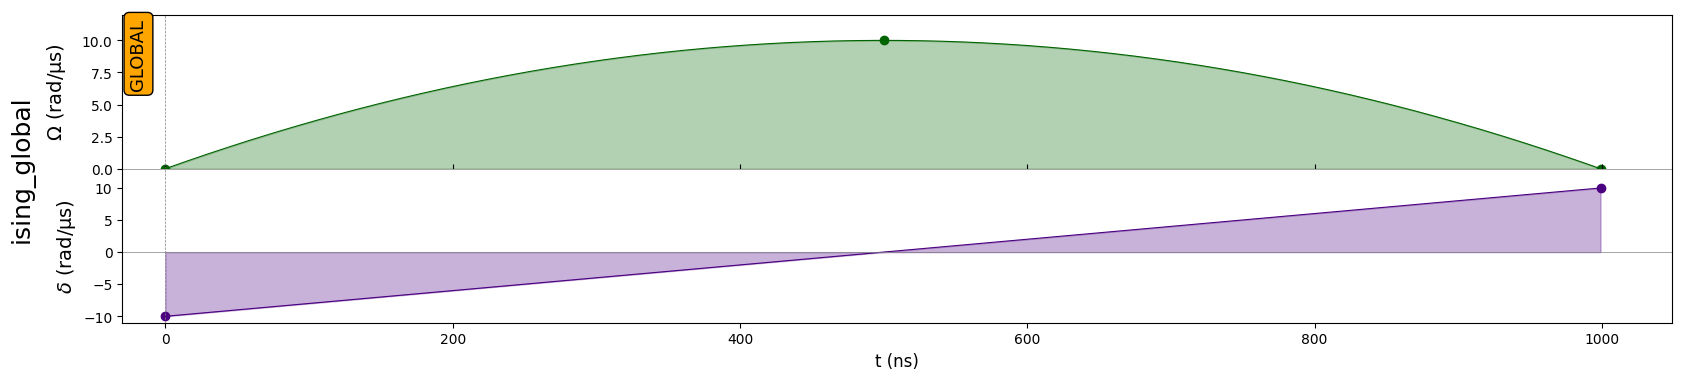

Atoms: 9
Duration: 1000 ns,  dt: 10 ns,  steps: 100


In [3]:
n_side = 3
n_atoms = n_side * n_side
spacing = 7.0  

reg = pulser.Register.square(n_side, prefix="q", spacing=spacing)

# --- Bare adiabatic protocol ------------------------------------------------
# Ω(t) ≡ 0  →  pure detuning sweep
# δ(t) goes from -delta_max to +delta_max linearly
T = 1000          # total duration in ns
dt = 10           # emulation timestep in ns
delta_max = 10.0  # rad/μs (Pulser convention)
omega_max = 10.0   # required by the problem statement
C6= AnalogDevice.interaction_coeff

adiabatic_pulse = pulser.Pulse(
    InterpolatedWaveform(T, [0,omega_max, 0]),         # Ω(t) = 0
    InterpolatedWaveform(T, [-delta_max, delta_max]),         # δ ramp
    0.0,
)

seq = pulser.Sequence(reg, pulser.MockDevice)
seq.declare_channel("ising_global", "rydberg_global")
seq.add(adiabatic_pulse, "ising_global")
seq.draw()
print(f"Atoms: {n_atoms}")
print(f"Duration: {T} ns,  dt: {dt} ns,  steps: {T // dt}")

In [4]:
target=dmrg_ground_state(seq)

emu-mps allows only {'correlation_matrix', 'bitstrings', 'occupation', 'energy_variance', 'energy', 'statistics', 'energy_second_moment'} observables with `optimize_qubit_ordering = True`. you provided unsupported {'state'} using `optimize_qubit_ordering = False` instead.
emu-mps allows only {'correlation_matrix', 'bitstrings', 'occupation', 'energy_variance', 'energy', 'statistics', 'energy_second_moment'} observables with `optimize_qubit_ordering = True`. you provided unsupported {'state'} using `optimize_qubit_ordering = False` instead.


/home/vvitale/pulse_counter_diabatic/.venv/lib/python3.10/site-packages/emu_base/math/krylov_energy_min.py:203: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at /pytorch/aten/src/ATen/native/Copy.cpp:307.)
  alphas[i] = torch.vdot(lanczos_vectors[i].reshape(-1), w.reshape(-1))


step = 1/10, χ = 6, |ψ| = 0.005 MB, RSS = 11.703 MB, Δt = 0.909 s
step = 2/10, χ = 10, |ψ| = 0.010 MB, RSS = 11.725 MB, Δt = 0.277 s
step = 3/10, χ = 11, |ψ| = 0.011 MB, RSS = 11.729 MB, Δt = 0.270 s
step = 4/10, χ = 12, |ψ| = 0.013 MB, RSS = 11.737 MB, Δt = 0.259 s
step = 5/10, χ = 13, |ψ| = 0.015 MB, RSS = 11.744 MB, Δt = 0.256 s
step = 6/10, χ = 13, |ψ| = 0.015 MB, RSS = 11.744 MB, Δt = 0.261 s
step = 7/10, χ = 14, |ψ| = 0.016 MB, RSS = 11.750 MB, Δt = 0.272 s
step = 8/10, χ = 14, |ψ| = 0.016 MB, RSS = 11.750 MB, Δt = 0.289 s
step = 9/10, χ = 11, |ψ| = 0.011 MB, RSS = 11.750 MB, Δt = 0.329 s
step = 10/10, χ = 6, |ψ| = 0.004 MB, RSS = 11.750 MB, Δt = 0.287 s


In [11]:
config_for_cd = MPSConfig(dt=dt, observables=[])

# LCD only
cd_lcd = CounterDiabaticPulse(seq, config_for_cd)
seq_data_lcd = cd_lcd.solver(cold_fourier=0)

# COLD 
cd_cold = CounterDiabaticPulse(seq, config_for_cd)
seq_data_cold = cd_cold.solver(cold_fourier=5, nruns=50, lr=1e-2)

/home/vvitale/pulse_counter_diabatic/.venv/lib/python3.10/site-packages/emu_mps/mps_config.py:111: UserWarning: 'MPSConfig' was initialized without any observables. The corresponding emulation results will be empty.
  super().__init__(


LCD  loss = 4.580067e+01  
step    0  loss = 4.580067e+01  
step    1  loss = 4.552857e+01  
step    2  loss = 4.527078e+01  
step    3  loss = 4.502691e+01  
step    4  loss = 4.479633e+01  
step    5  loss = 4.457810e+01  
step    6  loss = 4.437099e+01  
step    7  loss = 4.417349e+01  
step    8  loss = 4.398409e+01  
step    9  loss = 4.380147e+01  
step   10  loss = 4.362469e+01  
step   11  loss = 4.345321e+01  
step   12  loss = 4.328676e+01  
step   13  loss = 4.312524e+01  
step   14  loss = 4.296856e+01  
step   15  loss = 4.281659e+01  
step   16  loss = 4.266912e+01  
step   17  loss = 4.252586e+01  
step   18  loss = 4.238643e+01  
step   19  loss = 4.225046e+01  
step   20  loss = 4.211756e+01  
step   21  loss = 4.198746e+01  
step   22  loss = 4.185998e+01  
step   23  loss = 4.173504e+01  
step   24  loss = 4.161267e+01  
step   25  loss = 4.149294e+01  
step   26  loss = 4.137594e+01  
step   27  loss = 4.126173e+01  
step   28  loss = 4.115032e+01  
step   29  loss 

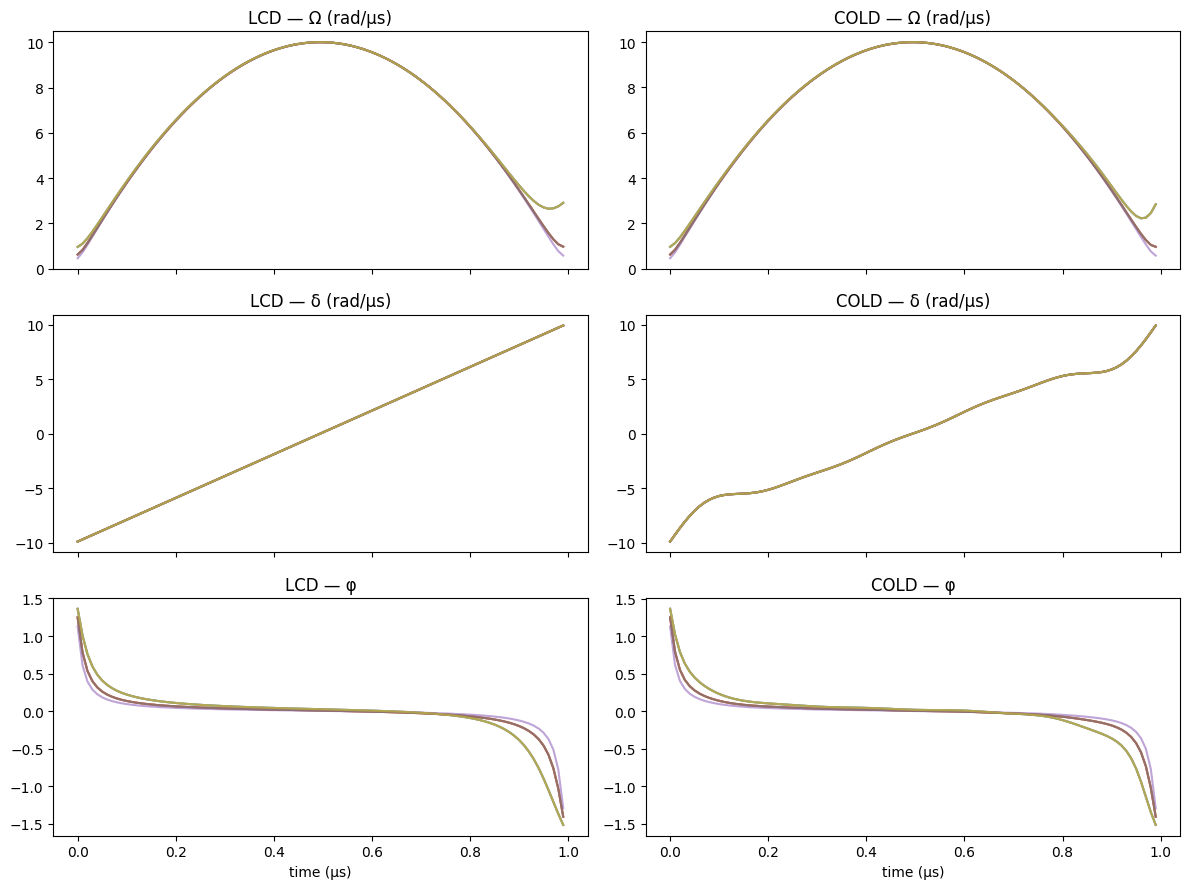

In [12]:
def to_np(t):
    return t.detach().cpu().numpy() if isinstance(t, torch.Tensor) else np.asarray(t)

times = np.arange(seq_data_lcd.omega.shape[0]) * dt / 1000  # in μs

fig, axes = plt.subplots(3, 2, figsize=(12, 9), sharex=True)
for col, (label, sd) in enumerate([("LCD", seq_data_lcd), ("COLD", seq_data_cold)]):
    omega = to_np(sd.omega)
    delta = to_np(sd.delta)
    phi   = to_np(sd.phi)
    for i in range(n_atoms):
        axes[0, col].plot(times, omega[:, i], alpha=0.6)
        axes[1, col].plot(times, delta[:, i], alpha=0.6)
        axes[2, col].plot(times, phi[:, i],   alpha=0.6)
    axes[0, col].set_title(f"{label} — Ω (rad/μs)")
    axes[1, col].set_title(f"{label} — δ (rad/μs)")
    axes[2, col].set_title(f"{label} — φ")
    axes[2, col].set_xlabel("time (μs)")
fig.tight_layout()
plt.show()

In [13]:
config = MPSConfig(
    dt=10,
    observables=[Fidelity(evaluation_times=[1.0], state=target),StateResult(evaluation_times=[1.0])])

print("Baseline schedule...")
backend = MPSBackend(seq, config=config)
results_baseline = backend.run()

emu-mps allows only {'correlation_matrix', 'bitstrings', 'occupation', 'energy_variance', 'energy', 'statistics', 'energy_second_moment'} observables with `optimize_qubit_ordering = True`. you provided unsupported {'fidelity', 'state'} using `optimize_qubit_ordering = False` instead.
Baseline schedule...
emu-mps allows only {'correlation_matrix', 'bitstrings', 'occupation', 'energy_variance', 'energy', 'statistics', 'energy_second_moment'} observables with `optimize_qubit_ordering = True`. you provided unsupported {'fidelity', 'state'} using `optimize_qubit_ordering = False` instead.
step = 1/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.750 MB, Δt = 0.070 s
step = 2/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.750 MB, Δt = 0.078 s
step = 3/100, χ = 2, |ψ| = 0.001 MB, RSS = 11.750 MB, Δt = 0.090 s
step = 4/100, χ = 2, |ψ| = 0.001 MB, RSS = 11.750 MB, Δt = 0.120 s
step = 5/100, χ = 3, |ψ| = 0.002 MB, RSS = 11.750 MB, Δt = 0.123 s
step = 6/100, χ = 4, |ψ| = 0.002 MB, RSS = 11.750 MB, Δt = 0.124 s
step = 

In [14]:
print("Emulating LCD schedule...")
results_lcd=MPSBackend._run_from_sequence_data(seq_data_lcd, config)


Emulating LCD schedule...


step = 1/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.750 MB, Δt = 0.083 s
step = 2/100, χ = 2, |ψ| = 0.001 MB, RSS = 11.750 MB, Δt = 0.085 s
step = 3/100, χ = 2, |ψ| = 0.001 MB, RSS = 11.750 MB, Δt = 0.116 s
step = 4/100, χ = 3, |ψ| = 0.002 MB, RSS = 11.750 MB, Δt = 0.123 s
step = 5/100, χ = 4, |ψ| = 0.003 MB, RSS = 11.750 MB, Δt = 0.124 s
step = 6/100, χ = 4, |ψ| = 0.003 MB, RSS = 11.750 MB, Δt = 0.124 s
step = 7/100, χ = 4, |ψ| = 0.003 MB, RSS = 11.750 MB, Δt = 0.125 s
step = 8/100, χ = 4, |ψ| = 0.003 MB, RSS = 11.750 MB, Δt = 0.125 s
step = 9/100, χ = 6, |ψ| = 0.005 MB, RSS = 11.750 MB, Δt = 0.140 s
step = 10/100, χ = 6, |ψ| = 0.005 MB, RSS = 11.750 MB, Δt = 0.147 s
step = 11/100, χ = 7, |ψ| = 0.006 MB, RSS = 11.750 MB, Δt = 0.147 s
step = 12/100, χ = 8, |ψ| = 0.008 MB, RSS = 11.750 MB, Δt = 0.154 s
step = 13/100, χ = 9, |ψ| = 0.009 MB, RSS = 11.750 MB, Δt = 0.171 s
step = 14/100, χ = 9, |ψ| = 0.009 MB, RSS = 11.750 MB, Δt = 0.167 s
step = 15/100, χ = 9, |ψ| = 0.009 MB, RSS = 11.750 MB, Δt

In [15]:
print("Emulating COLD schedule...")
results_cold=MPSBackend._run_from_sequence_data(seq_data_cold, config)

Emulating COLD schedule...


step = 1/100, χ = 1, |ψ| = 0.000 MB, RSS = 11.750 MB, Δt = 0.083 s
step = 2/100, χ = 2, |ψ| = 0.001 MB, RSS = 11.750 MB, Δt = 0.085 s
step = 3/100, χ = 3, |ψ| = 0.001 MB, RSS = 11.750 MB, Δt = 0.116 s
step = 4/100, χ = 3, |ψ| = 0.002 MB, RSS = 11.750 MB, Δt = 0.123 s
step = 5/100, χ = 4, |ψ| = 0.003 MB, RSS = 11.750 MB, Δt = 0.123 s
step = 6/100, χ = 4, |ψ| = 0.003 MB, RSS = 11.750 MB, Δt = 0.124 s
step = 7/100, χ = 4, |ψ| = 0.003 MB, RSS = 11.750 MB, Δt = 0.125 s
step = 8/100, χ = 4, |ψ| = 0.003 MB, RSS = 11.750 MB, Δt = 0.125 s
step = 9/100, χ = 6, |ψ| = 0.005 MB, RSS = 11.750 MB, Δt = 0.140 s
step = 10/100, χ = 7, |ψ| = 0.006 MB, RSS = 11.750 MB, Δt = 0.147 s
step = 11/100, χ = 7, |ψ| = 0.006 MB, RSS = 11.750 MB, Δt = 0.149 s
step = 12/100, χ = 8, |ψ| = 0.008 MB, RSS = 11.750 MB, Δt = 0.156 s
step = 13/100, χ = 9, |ψ| = 0.009 MB, RSS = 11.750 MB, Δt = 0.172 s
step = 14/100, χ = 9, |ψ| = 0.009 MB, RSS = 11.750 MB, Δt = 0.170 s
step = 15/100, χ = 9, |ψ| = 0.009 MB, RSS = 11.750 MB, Δt

In [16]:
fid_baseline = results_baseline.get_tagged_results()['fidelity']
fid_lcd  = results_lcd.get_tagged_results()['fidelity']
fid_cold = results_cold.get_tagged_results()['fidelity']

print(f"Baseline  ground-state fidelity: {fid_baseline}")
print(f"LCD  ground-state fidelity: {fid_lcd}")
print(f"COLD ground-state fidelity: {fid_cold}")

Baseline  ground-state fidelity: [tensor(0.1420, dtype=torch.float64)]
LCD  ground-state fidelity: [tensor(0.2072, dtype=torch.float64)]
COLD ground-state fidelity: [tensor(0.1672, dtype=torch.float64)]
